# Data Analysis and Preprocessing

## Imports

The autoreload instruction reloads modules automatically before code execution, which is helpful for the update below.

In [1]:
%load_ext autoreload
%autoreload 2

Make sure that we have the latest version of pandas-profiling and scikit-learn.

In [2]:
import sys

!{sys.executable} -m pip install -U pandas-profiling[notebook]
!jupyter nbextension enable --py widgetsnbextension

!pip uninstall scikit-learn -y
!pip install -U scikit-learn


Requirement already up-to-date: pandas-profiling[notebook] in /usr/local/lib/python3.7/dist-packages (2.11.0)
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK
Uninstalling scikit-learn-0.24.1:
  Successfully uninstalled scikit-learn-0.24.1
  Using cached https://files.pythonhosted.org/packages/f3/74/eb899f41d55f957e2591cde5528e75871f817d9fb46d4732423ecaca736d/scikit_learn-0.24.1-cp37-cp37m-manylinux2010_x86_64.whl


In [3]:
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.tree import DecisionTreeClassifier

import requests
import pandas_profiling as pp
from pandas_profiling.utils.cache import cache_file

In [4]:
print(sk.__version__)

print(pd.__version__)

0.24.1
1.1.5


## Constants

In [5]:
DATA_PATH = "https://raw.githubusercontent.com/serivan/mldmlab/master/Kaggle/KAGGLE21/"
RANDOM_STATE = 3993
COLLINEAR_THRESHOLD = 0.9
K_FEATURES = 3

## Load Data

In [16]:
dataset = pd.read_csv(DATA_PATH + "train.csv")

# Save the target column and drop the target
target = dataset["target"]
dataset.drop(columns="target", inplace=True)
# Sort columns by name
dataset.sort_index(axis="columns", inplace=True)
# Print first samples
dataset

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
0,1000,0.791547,60.0,4.0,207.0,1.0,0.0,131.0,2.355921,329.0,129.0,2.0,1.0,2.0
1,1001,0.751132,52.0,4.0,182.0,1.0,0.0,140.0,1.501970,347.0,129.0,0.0,0.0,2.0
2,1002,0.269111,48.0,4.0,224.0,0.0,0.0,186.0,-0.025627,462.0,122.0,2.0,1.0,1.0
3,1003,0.669550,60.0,3.0,320.0,1.0,1.0,122.0,1.654389,303.0,141.0,1.0,1.0,2.0
4,1004,0.533639,57.0,2.0,266.0,0.0,0.0,142.0,0.270579,351.0,123.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,2147,0.324488,55.0,4.0,NaN,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.0,2.0
1148,2148,0.326493,52.0,2.0,196.0,0.0,0.0,165.0,0.032431,411.0,161.0,0.0,1.0,1.0
1149,2149,0.647585,41.0,2.0,NaN,0.0,0.0,153.0,-0.027918,380.0,109.0,0.0,1.0,1.0
1150,2150,0.489609,61.0,4.0,205.0,1.0,0.0,137.0,1.905470,344.0,141.0,2.0,1.0,1.0


## Missing Values

Reasons for missing values
- Information is not collected (e.g., people decline to give their age and weight)
- Attributes may not be applicable to all cases (e.g., annual income is not applicable to children)

Handling missing values
- Eliminate Data Objects
- Estimate Missing Values
- Ignore the Missing Value During Analysis
- Replace with all possible values (weighted by their probabilities)

In [7]:
def count_missing(ds: pd.DataFrame):
    return ds.shape[0] - ds.count()

In [9]:
count_missing(dataset)

Id                       0
Synt                     0
age                      4
chest_pain_type         10
cholesterol            188
exercise_angina          3
fasting_blood_sugar      8
max_heart_rate           4
oldpeak                  7
pulse                    4
resting_bp_s             4
resting_ecg              3
sex                      9
st_slope                 1
dtype: int64

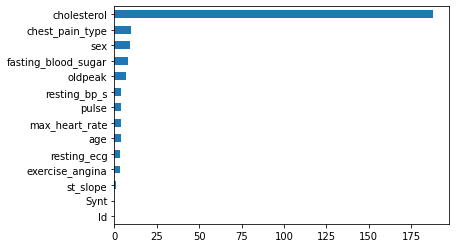

In [10]:
# Better visualization for missing count sorted by column
count_missing(dataset).sort_values().plot.barh()

In [11]:
def get_sample_with_nans(ds: pd.DataFrame):
    return ds.loc[ds.isna().any(axis=1)]

In [12]:
get_sample_with_nans(dataset)

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
5,1005,0.192692,64.0,1.0,NaN,1.0,0.0,144.0,1.844370,358.0,110.0,2.0,1.0,2.0
9,1009,0.506616,47.0,3.0,NaN,1.0,1.0,120.0,-0.004061,302.0,111.0,0.0,1.0,2.0
12,1012,0.822267,54.0,3.0,NaN,0.0,0.0,153.0,0.500606,378.0,124.0,2.0,1.0,3.0
15,1015,0.112264,50.0,4.0,218.0,1.0,0.0,127.0,1.073424,320.0,132.0,0.0,NaN,2.0
17,1017,0.011020,62.0,4.0,NaN,1.0,1.0,72.0,-0.481788,183.0,115.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,2141,0.455481,60.0,NaN,254.0,0.0,0.0,156.0,2.630425,392.0,150.0,2.0,0.0,2.0
1144,2144,0.489472,55.0,3.0,NaN,0.0,0.0,134.0,0.040049,335.0,121.0,2.0,1.0,1.0
1145,2145,0.091497,55.0,4.0,NaN,1.0,0.0,111.0,0.445751,278.0,140.0,0.0,1.0,2.0
1147,2147,0.324488,55.0,4.0,NaN,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.0,2.0


In [13]:
sample_with_nans_ids = get_sample_with_nans(dataset).index
sample_with_nans_ids

Int64Index([   5,    9,   12,   15,   17,   18,   23,   25,   30,   44,
            ...
            1119, 1122, 1129, 1138, 1140, 1141, 1144, 1145, 1147, 1149],
           dtype='int64', length=241)

### Eliminate Data Objects

In [14]:
dataset_no_nans = dataset.dropna()
dataset_no_nans

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
0,1000,0.791547,60.0,4.0,207.0,1.0,0.0,131.0,2.355921,329.0,129.0,2.0,1.0,2.0
1,1001,0.751132,52.0,4.0,182.0,1.0,0.0,140.0,1.501970,347.0,129.0,0.0,0.0,2.0
2,1002,0.269111,48.0,4.0,224.0,0.0,0.0,186.0,-0.025627,462.0,122.0,2.0,1.0,1.0
3,1003,0.669550,60.0,3.0,320.0,1.0,1.0,122.0,1.654389,303.0,141.0,1.0,1.0,2.0
4,1004,0.533639,57.0,2.0,266.0,0.0,0.0,142.0,0.270579,351.0,123.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,2143,0.503791,53.0,4.0,-5.0,1.0,0.0,140.0,1.982033,352.0,80.0,0.0,1.0,3.0
1146,2146,0.240049,60.0,2.0,266.0,0.0,1.0,157.0,0.514279,394.0,160.0,1.0,1.0,2.0
1148,2148,0.326493,52.0,2.0,196.0,0.0,0.0,165.0,0.032431,411.0,161.0,0.0,1.0,1.0
1150,2150,0.489609,61.0,4.0,205.0,1.0,0.0,137.0,1.905470,344.0,141.0,2.0,1.0,1.0


In [17]:
count_missing(dataset_no_nans)

Id                     0
Synt                   0
age                    0
chest_pain_type        0
cholesterol            0
exercise_angina        0
fasting_blood_sugar    0
max_heart_rate         0
oldpeak                0
pulse                  0
resting_bp_s           0
resting_ecg            0
sex                    0
st_slope               0
dtype: int64

In [18]:
try:
    dataset_no_nans.loc[sample_with_nans_ids]
except KeyError:
    print("Ids of desired samples are not in dataset!")

Ids of desired samples are not in dataset!


### Impute Missing Values

Estimate missing values can be performed using both pandas and scikit-learn.
We use scikit-learn because it helps with machine learning.

In [19]:
def array_to_dataframe(arr: np.ndarray, columns: List[str]):
    return pd.DataFrame(data=arr, columns=columns)

#### Impute with constant

In [20]:
constant_imp_arr = SimpleImputer(strategy="constant", fill_value=-1).fit_transform(
    dataset
)
constant_imp_arr

array([[1.00000000e+03, 7.91547406e-01, 6.00000000e+01, ...,
        2.00000000e+00, 1.00000000e+00, 2.00000000e+00],
       [1.00100000e+03, 7.51132372e-01, 5.20000000e+01, ...,
        0.00000000e+00, 0.00000000e+00, 2.00000000e+00],
       [1.00200000e+03, 2.69111391e-01, 4.80000000e+01, ...,
        2.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       ...,
       [2.14900000e+03, 6.47585087e-01, 4.10000000e+01, ...,
        0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [2.15000000e+03, 4.89608600e-01, 6.10000000e+01, ...,
        2.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [2.15100000e+03, 7.51959670e-02, 5.40000000e+01, ...,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])

In [21]:
constant_imp_df = array_to_dataframe(constant_imp_arr, dataset.columns)

In [22]:
count_missing(constant_imp_df)

Id                     0
Synt                   0
age                    0
chest_pain_type        0
cholesterol            0
exercise_angina        0
fasting_blood_sugar    0
max_heart_rate         0
oldpeak                0
pulse                  0
resting_bp_s           0
resting_ecg            0
sex                    0
st_slope               0
dtype: int64

In [23]:
constant_imp_df.loc[sample_with_nans_ids]

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
5,1005.0,0.192692,64.0,1.0,-1.0,1.0,0.0,144.0,1.844370,358.0,110.0,2.0,1.0,2.0
9,1009.0,0.506616,47.0,3.0,-1.0,1.0,1.0,120.0,-0.004061,302.0,111.0,0.0,1.0,2.0
12,1012.0,0.822267,54.0,3.0,-1.0,0.0,0.0,153.0,0.500606,378.0,124.0,2.0,1.0,3.0
15,1015.0,0.112264,50.0,4.0,218.0,1.0,0.0,127.0,1.073424,320.0,132.0,0.0,-1.0,2.0
17,1017.0,0.011020,62.0,4.0,-1.0,1.0,1.0,72.0,-0.481788,183.0,115.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,2141.0,0.455481,60.0,-1.0,254.0,0.0,0.0,156.0,2.630425,392.0,150.0,2.0,0.0,2.0
1144,2144.0,0.489472,55.0,3.0,-1.0,0.0,0.0,134.0,0.040049,335.0,121.0,2.0,1.0,1.0
1145,2145.0,0.091497,55.0,4.0,-1.0,1.0,0.0,111.0,0.445751,278.0,140.0,0.0,1.0,2.0
1147,2147.0,0.324488,55.0,4.0,-1.0,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.0,2.0


#### Impute with mean or median

In [28]:
median_imp_arr = SimpleImputer(strategy="median").fit_transform(dataset)
median_imp_df = array_to_dataframe(arr=median_imp_arr, columns=dataset.columns)
median_imp_df

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
0,1000.0,0.791547,60.0,4.0,207.0,1.0,0.0,131.0,2.355921,329.0,129.0,2.0,1.0,2.0
1,1001.0,0.751132,52.0,4.0,182.0,1.0,0.0,140.0,1.501970,347.0,129.0,0.0,0.0,2.0
2,1002.0,0.269111,48.0,4.0,224.0,0.0,0.0,186.0,-0.025627,462.0,122.0,2.0,1.0,1.0
3,1003.0,0.669550,60.0,3.0,320.0,1.0,1.0,122.0,1.654389,303.0,141.0,1.0,1.0,2.0
4,1004.0,0.533639,57.0,2.0,266.0,0.0,0.0,142.0,0.270579,351.0,123.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,2147.0,0.324488,55.0,4.0,230.0,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.0,2.0
1148,2148.0,0.326493,52.0,2.0,196.0,0.0,0.0,165.0,0.032431,411.0,161.0,0.0,1.0,1.0
1149,2149.0,0.647585,41.0,2.0,230.0,0.0,0.0,153.0,-0.027918,380.0,109.0,0.0,1.0,1.0
1150,2150.0,0.489609,61.0,4.0,205.0,1.0,0.0,137.0,1.905470,344.0,141.0,2.0,1.0,1.0


In [25]:
count_missing(median_imp_df)

Id                     0
Synt                   0
age                    0
chest_pain_type        0
cholesterol            0
exercise_angina        0
fasting_blood_sugar    0
max_heart_rate         0
oldpeak                0
pulse                  0
resting_bp_s           0
resting_ecg            0
sex                    0
st_slope               0
dtype: int64

In [26]:
median_imp_df.loc[sample_with_nans_ids]

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
5,1005.0,0.192692,64.0,1.0,230.0,1.0,0.0,144.0,1.844370,358.0,110.0,2.0,1.0,2.0
9,1009.0,0.506616,47.0,3.0,230.0,1.0,1.0,120.0,-0.004061,302.0,111.0,0.0,1.0,2.0
12,1012.0,0.822267,54.0,3.0,230.0,0.0,0.0,153.0,0.500606,378.0,124.0,2.0,1.0,3.0
15,1015.0,0.112264,50.0,4.0,218.0,1.0,0.0,127.0,1.073424,320.0,132.0,0.0,1.0,2.0
17,1017.0,0.011020,62.0,4.0,230.0,1.0,1.0,72.0,-0.481788,183.0,115.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,2141.0,0.455481,60.0,3.0,254.0,0.0,0.0,156.0,2.630425,392.0,150.0,2.0,0.0,2.0
1144,2144.0,0.489472,55.0,3.0,230.0,0.0,0.0,134.0,0.040049,335.0,121.0,2.0,1.0,1.0
1145,2145.0,0.091497,55.0,4.0,230.0,1.0,0.0,111.0,0.445751,278.0,140.0,0.0,1.0,2.0
1147,2147.0,0.324488,55.0,4.0,230.0,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.0,2.0


#### Impute with KNearestNeighbours

In [29]:
knn_imp_arr = KNNImputer().fit_transform(dataset)
knn_imp_df = array_to_dataframe(arr=knn_imp_arr, columns=dataset.columns)
knn_imp_df

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
0,1000.0,0.791547,60.0,4.0,207.0,1.0,0.0,131.0,2.355921,329.0,129.0,2.0,1.0,2.0
1,1001.0,0.751132,52.0,4.0,182.0,1.0,0.0,140.0,1.501970,347.0,129.0,0.0,0.0,2.0
2,1002.0,0.269111,48.0,4.0,224.0,0.0,0.0,186.0,-0.025627,462.0,122.0,2.0,1.0,1.0
3,1003.0,0.669550,60.0,3.0,320.0,1.0,1.0,122.0,1.654389,303.0,141.0,1.0,1.0,2.0
4,1004.0,0.533639,57.0,2.0,266.0,0.0,0.0,142.0,0.270579,351.0,123.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,2147.0,0.324488,55.0,4.0,224.8,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.0,2.0
1148,2148.0,0.326493,52.0,2.0,196.0,0.0,0.0,165.0,0.032431,411.0,161.0,0.0,1.0,1.0
1149,2149.0,0.647585,41.0,2.0,225.6,0.0,0.0,153.0,-0.027918,380.0,109.0,0.0,1.0,1.0
1150,2150.0,0.489609,61.0,4.0,205.0,1.0,0.0,137.0,1.905470,344.0,141.0,2.0,1.0,1.0


In [30]:
count_missing(knn_imp_df)

Id                     0
Synt                   0
age                    0
chest_pain_type        0
cholesterol            0
exercise_angina        0
fasting_blood_sugar    0
max_heart_rate         0
oldpeak                0
pulse                  0
resting_bp_s           0
resting_ecg            0
sex                    0
st_slope               0
dtype: int64

In [31]:
knn_imp_df.loc[sample_with_nans_ids]

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
5,1005.0,0.192692,64.0,1.0,255.4,1.0,0.0,144.0,1.844370,358.0,110.0,2.0,1.0,2.0
9,1009.0,0.506616,47.0,3.0,282.0,1.0,1.0,120.0,-0.004061,302.0,111.0,0.0,1.0,2.0
12,1012.0,0.822267,54.0,3.0,263.4,0.0,0.0,153.0,0.500606,378.0,124.0,2.0,1.0,3.0
15,1015.0,0.112264,50.0,4.0,218.0,1.0,0.0,127.0,1.073424,320.0,132.0,0.0,1.0,2.0
17,1017.0,0.011020,62.0,4.0,152.8,1.0,1.0,72.0,-0.481788,183.0,115.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,2141.0,0.455481,60.0,2.6,254.0,0.0,0.0,156.0,2.630425,392.0,150.0,2.0,0.0,2.0
1144,2144.0,0.489472,55.0,3.0,202.6,0.0,0.0,134.0,0.040049,335.0,121.0,2.0,1.0,1.0
1145,2145.0,0.091497,55.0,4.0,222.0,1.0,0.0,111.0,0.445751,278.0,140.0,0.0,1.0,2.0
1147,2147.0,0.324488,55.0,4.0,224.8,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.0,2.0


#### Impute with IterativeImputer ([BayesianRidge](https://www.tutorialspoint.com/scikit_learn/scikit_learn_bayesian_ridge_regression.htm))

In [33]:
iter_imp_arr = IterativeImputer().fit_transform(dataset)
iter_imp_df = array_to_dataframe(arr=iter_imp_arr, columns=dataset.columns)
iter_imp_df

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
0,1000.0,0.791547,60.0,4.0,207.000000,1.0,0.0,131.0,2.355921,329.0,129.0,2.0,1.0,2.0
1,1001.0,0.751132,52.0,4.0,182.000000,1.0,0.0,140.0,1.501970,347.0,129.0,0.0,0.0,2.0
2,1002.0,0.269111,48.0,4.0,224.000000,0.0,0.0,186.0,-0.025627,462.0,122.0,2.0,1.0,1.0
3,1003.0,0.669550,60.0,3.0,320.000000,1.0,1.0,122.0,1.654389,303.0,141.0,1.0,1.0,2.0
4,1004.0,0.533639,57.0,2.0,266.000000,0.0,0.0,142.0,0.270579,351.0,123.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,2147.0,0.324488,55.0,4.0,212.755873,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.0,2.0
1148,2148.0,0.326493,52.0,2.0,196.000000,0.0,0.0,165.0,0.032431,411.0,161.0,0.0,1.0,1.0
1149,2149.0,0.647585,41.0,2.0,213.921935,0.0,0.0,153.0,-0.027918,380.0,109.0,0.0,1.0,1.0
1150,2150.0,0.489609,61.0,4.0,205.000000,1.0,0.0,137.0,1.905470,344.0,141.0,2.0,1.0,1.0


In [34]:
count_missing(iter_imp_df)

Id                     0
Synt                   0
age                    0
chest_pain_type        0
cholesterol            0
exercise_angina        0
fasting_blood_sugar    0
max_heart_rate         0
oldpeak                0
pulse                  0
resting_bp_s           0
resting_ecg            0
sex                    0
st_slope               0
dtype: int64

In [35]:
iter_imp_df.loc[sample_with_nans_ids]

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,pulse,resting_bp_s,resting_ecg,sex,st_slope
5,1005.0,0.192692,64.0,1.000000,208.774810,1.0,0.0,144.0,1.844370,358.0,110.0,2.0,1.000000,2.0
9,1009.0,0.506616,47.0,3.000000,181.204505,1.0,1.0,120.0,-0.004061,302.0,111.0,0.0,1.000000,2.0
12,1012.0,0.822267,54.0,3.000000,219.077798,0.0,0.0,153.0,0.500606,378.0,124.0,2.0,1.000000,3.0
15,1015.0,0.112264,50.0,4.000000,218.000000,1.0,0.0,127.0,1.073424,320.0,132.0,0.0,0.763762,2.0
17,1017.0,0.011020,62.0,4.000000,140.689818,1.0,1.0,72.0,-0.481788,183.0,115.0,0.0,1.000000,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,2141.0,0.455481,60.0,2.907307,254.000000,0.0,0.0,156.0,2.630425,392.0,150.0,2.0,0.000000,2.0
1144,2144.0,0.489472,55.0,3.000000,205.447768,0.0,0.0,134.0,0.040049,335.0,121.0,2.0,1.000000,1.0
1145,2145.0,0.091497,55.0,4.000000,190.337108,1.0,0.0,111.0,0.445751,278.0,140.0,0.0,1.000000,2.0
1147,2147.0,0.324488,55.0,4.000000,212.755873,1.0,0.0,116.0,3.371668,295.0,179.0,1.0,0.000000,2.0


## Aggregation 

Combining two or more attributes (or objects) into a single attribute (or object)

Purpose
- Data reduction: Reduce the number of attributes or objects
- Change of scale: Cities aggregated into regions, states, countries, etc
- More “stable” data: Aggregated data tends to have less variability 



See also https://www.tutorialspoint.com/scikit_learn/scikit_learn_bayesian_ridge_regression.htm

In [36]:
dataset.groupby([ 'sex', 'chest_pain_type']).size().unstack()

chest_pain_type,1.0,2.0,3.0,4.0
sex,,,,
0.0,14,88,98,99
1.0,52,142,198,442


Another more flexible way is to use crosstab():

In [37]:
pd.crosstab(dataset['sex'], dataset['chest_pain_type'])


chest_pain_type,1.0,2.0,3.0,4.0
sex,,,,
0.0,14,88,98,99
1.0,52,142,198,442


In [38]:
pd.crosstab(dataset['sex'], dataset['chest_pain_type'], margins=True)

chest_pain_type,1.0,2.0,3.0,4.0,All
sex,,,,,
0.0,14,88,98,99,299
1.0,52,142,198,442,834
All,66,230,296,541,1133


In [39]:
pd.crosstab(dataset['sex'], dataset['chest_pain_type'], margins=True, normalize=True)

chest_pain_type,1.0,2.0,3.0,4.0,All
sex,,,,,
0.0,0.012357,0.077670,0.086496,0.087379,0.263901
1.0,0.045896,0.125331,0.174757,0.390115,0.736099
All,0.058252,0.203001,0.261253,0.477493,1.000000


You can use groupby() with describe() for group summary statistics

In [40]:
dataset.groupby('sex')['chest_pain_type'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
0.0,299.0,2.943144,0.901217,1.0,2.0,3.0,4.0,4.0
1.0,834.0,3.235012,0.946300,1.0,3.0,4.0,4.0,4.0


In [41]:
dataset.groupby('sex')['chest_pain_type'].describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
0.0,299.0,2.943144,0.901217,1.0,2.0,3.0,4.0,4.0
1.0,834.0,3.235012,0.946300,1.0,3.0,4.0,4.0,4.0


You can use agg()/aggregate() for flexible aggregations

In [42]:
dataset.groupby(['sex']).agg({'chest_pain_type': ['mean', 'std']}) 

chest_pain_type          
               mean       std
sex                          
0.0        2.943144  0.901217
1.0        3.235012  0.946300

In [43]:
dataset.groupby(['sex']).agg({'chest_pain_type': ['mean', 'std'], 'cholesterol': ['mean', 'std']}) 

chest_pain_type           cholesterol            
               mean       std        mean         std
sex                                                  
0.0        2.943144  0.901217  252.899598   78.412076
1.0        3.235012  0.946300  199.420680  102.175264

and take advantage of pivot_table()

In [44]:
dataset.pivot_table(values='cholesterol', index='sex', columns='chest_pain_type')

chest_pain_type,1.0,2.0,3.0,4.0
sex,,,,
0.0,227.000000,257.768116,256.011765,245.3375
1.0,213.880952,225.474576,189.433735,194.0640


###  Data reduction

#### Drop collinear columns

In [45]:
def get_collinear_cols(ds: pd.DataFrame, coll_threshold: float):
    # Compute correlation matrix using pearson method (linear correlation)
    corr = iter_imp_df.corr(method="pearson")
    # Find collinear columns
    coll_cols = corr[corr > coll_threshold].dropna(thresh=2).dropna(axis="columns")
    return coll_cols

In [46]:
get_collinear_cols(ds=dataset, coll_threshold=COLLINEAR_THRESHOLD)

,max_heart_rate,pulse
max_heart_rate,1.000000,0.999148
pulse,0.999148,1.000000


In [47]:
# Drop collinear column
iter_imp_df.drop(columns=["pulse"], inplace=True)
iter_imp_df

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,resting_bp_s,resting_ecg,sex,st_slope
0,1000.0,0.791547,60.0,4.0,207.000000,1.0,0.0,131.0,2.355921,129.0,2.0,1.0,2.0
1,1001.0,0.751132,52.0,4.0,182.000000,1.0,0.0,140.0,1.501970,129.0,0.0,0.0,2.0
2,1002.0,0.269111,48.0,4.0,224.000000,0.0,0.0,186.0,-0.025627,122.0,2.0,1.0,1.0
3,1003.0,0.669550,60.0,3.0,320.000000,1.0,1.0,122.0,1.654389,141.0,1.0,1.0,2.0
4,1004.0,0.533639,57.0,2.0,266.000000,0.0,0.0,142.0,0.270579,123.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1147,2147.0,0.324488,55.0,4.0,212.755873,1.0,0.0,116.0,3.371668,179.0,1.0,0.0,2.0
1148,2148.0,0.326493,52.0,2.0,196.000000,0.0,0.0,165.0,0.032431,161.0,0.0,1.0,1.0
1149,2149.0,0.647585,41.0,2.0,213.921935,0.0,0.0,153.0,-0.027918,109.0,0.0,1.0,1.0
1150,2150.0,0.489609,61.0,4.0,205.000000,1.0,0.0,137.0,1.905470,141.0,2.0,1.0,1.0


## Types of Sampling

- *Simple Random Sampling*: There is an equal probability of selecting any particular item
    - Sampling without replacement: As each item is selected, it is removed from the population
    - Sampling with replacement: Objects are not removed from the population as they are selected for the sample.In sampling with replacement, the same object can be picked up more than once
- *Stratified sampling*: Split the data into several partitions; then draw random samples from each partition

### Random Sampling

Random samplig 20% of the data without replacement

In [48]:
def get_repeated_index(ds: pd.DataFrame):
    return ds.index.value_counts()[ds.index.value_counts() > 1]

In [49]:
randsamp = iter_imp_df.sample(frac=0.2, random_state=RANDOM_STATE)
randsamp

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,resting_bp_s,resting_ecg,sex,st_slope
958,1958.0,0.373153,42.0,2.0,199.000000,0.0,0.0,149.0,-0.002512,121.0,0.0,1.0,1.0
127,1127.0,0.665822,37.0,3.0,213.000000,0.0,0.0,143.0,-0.008179,131.0,0.0,0.0,1.0
160,1160.0,0.433280,50.0,3.0,235.000000,0.0,0.0,162.0,0.610275,140.0,0.0,1.0,2.0
985,1985.0,0.796807,39.0,3.0,199.000000,0.0,0.0,179.0,-0.029256,93.0,0.0,0.0,1.0
1135,2135.0,0.094556,32.0,2.0,253.000000,0.0,0.0,155.0,0.013186,125.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,1384.0,0.706974,52.0,4.0,226.492160,1.0,1.0,156.0,1.021497,129.0,0.0,1.0,2.0
668,1668.0,0.346702,34.0,1.0,153.000000,0.0,0.0,180.0,-0.033906,141.0,0.0,1.0,2.0
1061,2061.0,0.705160,66.0,3.0,215.000000,1.0,1.0,100.0,1.341730,110.0,2.0,1.0,2.0
959,1959.0,0.399942,65.0,1.0,215.991482,0.0,0.0,134.0,0.261265,141.0,0.0,1.0,1.0


In [50]:
get_repeated_index(randsamp)

Series([], dtype: int64)

Random sampling 20% of the data with replacement

In [51]:
randsamp_with_rep = iter_imp_df.sample(
    frac=0.2, replace=True, random_state=RANDOM_STATE
)
randsamp_with_rep

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,resting_bp_s,resting_ecg,sex,st_slope
814,1814.0,0.322193,57.0,4.000000,299.000000,0.0,0.0,159.0,0.050407,127.000000,2.0,0.0,1.0
1074,2074.0,0.846127,61.0,4.000000,211.000000,1.0,0.0,138.0,1.845972,140.000000,2.0,1.0,1.0
121,1121.0,0.850621,58.0,3.000000,218.000000,0.0,0.0,140.0,0.046759,130.000000,1.0,1.0,2.0
844,1844.0,0.490775,50.0,4.000000,186.904844,1.0,0.0,121.0,0.510493,115.000000,0.0,1.0,2.0
100,1100.0,0.545470,60.0,3.641744,285.000000,1.0,0.0,141.0,2.746105,145.000000,2.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,1656.0,0.431904,59.0,3.000000,217.000000,0.0,1.0,158.0,1.570173,149.000000,0.0,1.0,1.0
299,1299.0,0.465777,40.0,2.000000,215.295339,0.0,0.0,149.0,0.023329,129.000000,0.0,1.0,1.0
266,1266.0,0.260621,53.0,4.000000,228.774121,1.0,1.0,156.0,3.090907,136.037423,2.0,1.0,3.0
209,1209.0,0.430254,62.0,4.000000,169.000000,1.0,0.0,139.0,-0.020979,158.000000,1.0,1.0,2.0


In [52]:
get_repeated_index(randsamp_with_rep)

814     3
600     3
1002    2
687     2
881     2
189     2
107     2
1071    2
338     2
910     2
512     2
892     2
1008    2
dtype: int64

### Stratified Sampling

In [53]:
def plot_pie_values_col(ds: pd.DataFrame, column: str):
    ds[column].value_counts()[ds[column].value_counts() > 3].plot.pie(
        figsize=(8, 6), autopct="%1.1f%%"
    )
    plt.show()

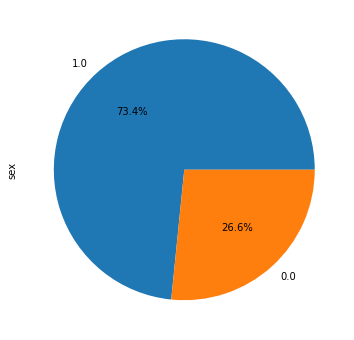

In [54]:
plot_pie_values_col(ds=iter_imp_df, column="sex")

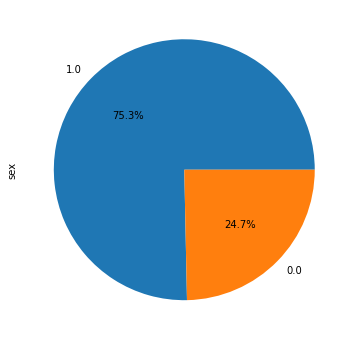

In [55]:
plot_pie_values_col(ds=randsamp, column="sex")

In [56]:
stratsamp = iter_imp_df.groupby("sex", group_keys=False).apply(
    lambda x: x.sample(frac=0.2)
)
stratsamp

,Id,Synt,age,chest_pain_type,cholesterol,exercise_angina,fasting_blood_sugar,max_heart_rate,oldpeak,resting_bp_s,resting_ecg,sex,st_slope
815,1815.0,0.407086,63.0,2.0,258.227501,0.0,0.0,179.0,-0.040171,140.0,0.000000,0.0,1.0
327,1327.0,0.624542,54.0,2.0,212.145015,0.0,0.0,129.0,0.033867,160.0,0.000000,0.0,1.0
376,1376.0,0.429798,54.0,3.0,302.000000,0.0,1.0,170.0,0.017797,135.0,0.000000,0.0,1.0
871,1871.0,0.347835,68.0,3.0,188.637262,0.0,0.0,114.0,1.452896,120.0,2.000000,0.0,2.0
97,1097.0,0.626055,71.0,3.0,270.000000,0.0,1.0,129.0,-0.022753,111.0,2.000000,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
961,1961.0,0.967580,56.0,3.0,3.000000,0.0,0.0,100.0,0.031618,155.0,1.000000,1.0,2.0
912,1912.0,0.698435,56.0,3.0,-5.000000,0.0,0.0,96.0,-0.053168,121.0,0.323705,1.0,2.0
1145,2145.0,0.091497,55.0,4.0,190.337108,1.0,0.0,111.0,0.445751,140.0,0.000000,1.0,2.0
734,1734.0,0.427774,47.0,4.0,227.000000,1.0,0.0,98.0,1.496663,149.0,0.000000,1.0,2.0


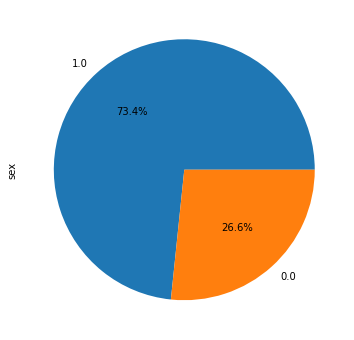

In [57]:
plot_pie_values_col(stratsamp, column="sex")

## Principal Component Analysis

In [81]:
# Decomposition of PCA
pca_decomp = PCA(n_components=2, whiten=True, random_state=RANDOM_STATE)
pca_decomp = pca_decomp.fit(iter_imp_df)

# Dataset PCA as Numpy array
iter_imp_pca_arr = pca_decomp.transform(iter_imp_df)

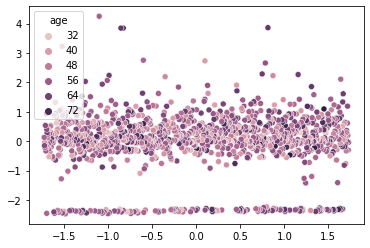

In [59]:
# Plot the pca clustered by age
sns.scatterplot(
    x=iter_imp_pca_arr[:, 0], y=iter_imp_pca_arr[:, 1], hue=iter_imp_df["age"]
)

## Feature Subset Selection

Techniques:
- Brute-force approach: Try all possible feature subsets as input to data mining algorithm
- Embedded approaches: Feature selection occurs naturally as part of the data mining algorithm
- Filter approaches: Features are selected before data mining algorithm is run
- Wrapper approaches: Use the data mining algorithm as a black box to find best subset of attributes

Techniques:
- Univariate approach:
    - KBest: Select features according to the k highest scores in univariate fashion (default using Analysis of Variance, aka ANOVA, scores).
- ModelBased approach: Feature selection using an estimator for feature ranking
    - Recursive Feature Elimination: Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), the goal of recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features.
    - Sequential Feature Selection: This Sequential Feature Selector adds (forward selection) or removes (backward selection) features to form a feature subset in a greedy fashion.
    - Select From Model: Meta-transformer for selecting features based on importance weights.

### Univariate Approach

In [60]:
def get_feature_univ_scores(univ_fselector, columns, sort_by: str = "score"):
    return pd.DataFrame(
        data=[univ_fselector.scores_, univ_fselector.pvalues_],
        index=["score", "pvalue"],
        columns=columns,
    ).T.sort_values(by=sort_by, ascending=False)

#### Select KBest

In [61]:
# Create the feature selector
kbest = SelectKBest(k=3)
kbest.fit(iter_imp_df, target)

SelectKBest(k=3)

In [62]:
# Print selected columns
iter_imp_df.columns[kbest.get_support()]

Index(['chest_pain_type', 'exercise_angina', 'st_slope'], dtype='object')

In [63]:
# Feature selection scores and pvalues analysis
get_feature_univ_scores(kbest, iter_imp_df.columns, sort_by="score")

,score,pvalue
st_slope,385.312318,3.226314e-74
exercise_angina,376.332810,9.491525e-73
chest_pain_type,271.713461,5.802042e-55
max_heart_rate,249.114856,6.026593e-51
oldpeak,243.315709,6.629012e-50
sex,127.677019,3.779674e-28
age,70.205698,1.541034e-16
fasting_blood_sugar,66.182263,1.057621e-15
cholesterol,46.783478,1.285098e-11
resting_bp_s,22.218921,2.730127e-06


In [64]:
# Transform dataset selection columns
kbest.transform(iter_imp_df)

array([[4., 1., 2.],
       [4., 1., 2.],
       [4., 0., 1.],
       ...,
       [2., 0., 1.],
       [4., 1., 1.],
       [2., 0., 1.]])

### ModelBased Approach

#### Recursive Feature Elimination (Based On Regression)

In [65]:
def get_feature_rfe_ranking(
    mb_fselector, columns,
):
    return pd.DataFrame(
        data=[mb_fselector.ranking_], index=["ranking"], columns=columns,
    ).T.sort_values(by="ranking", ascending=True)

In [66]:
# Create the RecursiveFeatureElimination selector
rfe = RFE(
    estimator=LinearRegression(normalize=True), n_features_to_select=K_FEATURES, step=1
)
rfe.fit(iter_imp_df, target)

RFE(estimator=LinearRegression(normalize=True), n_features_to_select=3)

In [67]:
# Print selected columns
iter_imp_df.columns[rfe.support_]

Index(['exercise_angina', 'sex', 'st_slope'], dtype='object')

In [68]:
# Analyze feature ranking
get_feature_rfe_ranking(rfe, iter_imp_df.columns)

,ranking
exercise_angina,1
sex,1
st_slope,1
fasting_blood_sugar,2
chest_pain_type,3
oldpeak,4
Synt,5
resting_ecg,6
max_heart_rate,7
age,8


In [69]:
rfe.transform(iter_imp_df)

array([[1., 1., 2.],
       [1., 0., 2.],
       [0., 1., 1.],
       ...,
       [0., 1., 1.],
       [1., 1., 1.],
       [0., 0., 1.]])

#### Sequential Feature Selection (Based on Classification)

In [70]:
# Create the RecursiveFeatureElimination selector
sfs = SequentialFeatureSelector(
    estimator=DecisionTreeClassifier(max_depth=4),
    n_features_to_select=K_FEATURES,
    cv=5,
)
sfs.fit(iter_imp_df, target)

SequentialFeatureSelector(estimator=DecisionTreeClassifier(max_depth=4),
                          n_features_to_select=3)

In [71]:
# Print selected columns
iter_imp_df.columns[sfs.support_]

Index(['chest_pain_type', 'oldpeak', 'st_slope'], dtype='object')

In [72]:
sfs.transform(iter_imp_df)

array([[ 4.        ,  2.35592054,  2.        ],
       [ 4.        ,  1.50197009,  2.        ],
       [ 4.        , -0.02562722,  1.        ],
       ...,
       [ 2.        , -0.02791818,  1.        ],
       [ 4.        ,  1.90546989,  1.        ],
       [ 2.        ,  0.01344436,  1.        ]])

#### Select From Model

In [73]:
# Create the SelectFromModel selector
sfm = SelectFromModel(estimator=Lasso(), max_features=K_FEATURES)
sfm.fit(iter_imp_df, target)

SelectFromModel(estimator=Lasso(), max_features=3)

In [74]:
# Print selected columns
iter_imp_df.columns[sfm.get_support()]

Index(['cholesterol', 'max_heart_rate', 'resting_bp_s'], dtype='object')

In [75]:
sfm.transform(iter_imp_df)

array([[207.        , 131.        , 129.        ],
       [182.        , 140.        , 129.        ],
       [224.        , 186.        , 122.        ],
       ...,
       [213.92193538, 153.        , 109.        ],
       [205.        , 137.        , 141.        ],
       [231.        , 131.        , 150.        ]])

## Feature Construction

In [76]:
# Create a new feature called relative_bp_s as the ratio between resting blood pressure and cholesterol
iter_imp_df["bp_s_chol"] = iter_imp_df["resting_bp_s"] / (
    iter_imp_df["cholesterol"] + 1e-7
)
iter_imp_df["bp_s_chol"]

0       0.623188
1       0.708791
2       0.544643
3       0.440625
4       0.462406
          ...   
1147    0.841340
1148    0.821429
1149    0.509532
1150    0.687805
1151    0.649351
Name: bp_s_chol, Length: 1152, dtype: float64

## Attribute Transformation

In [77]:
# Apply logaritmic transformation and create a new transformed column
iter_imp_df["transformed_mhr"] = iter_imp_df["max_heart_rate"].apply(
    lambda x: max(min(x - x / np.sqrt(x), 120), 90)
)

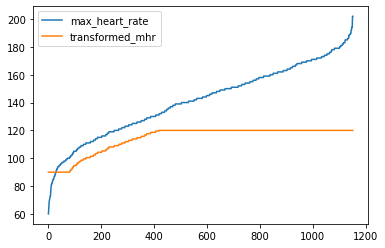

In [78]:
# Visualize the current transformation
iter_imp_df[["max_heart_rate", "transformed_mhr"]].sort_values(
    by="max_heart_rate", ignore_index=True
).plot.line()

## Data profiling


In [79]:
!pip freeze |grep pandas-profiling


pandas-profiling==2.11.0


In [80]:
pp.ProfileReport(dataset)

Output hidden; open in https://colab.research.google.com to view.